# HBV hydrological model forced with DestinE SSP370 forcing data
In this notebook we will generate forcing data for the HBV hydrological model from the output of project DestinE, simulating the SSP370 CMIP6 scenario climate model using the eWaterCycle platform. eWaterCycles integration of DestinE data is still quite new 

The code in this notebook is nearly identical to the code in [this notebook](step_1a_generate_historical_forcing.ipynb) where we generated both ERA5 and historical CMIP6 forcing data. For detailed descriptions, see that notebook.

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import json
from esmvalcore.config import CFG
import time

# Niceties
from rich import print

# destinE
from forcing_destine import DestinEForcing
from dest_auth import authenticate as dest_auth
dest_auth()

Authenticating on https://auth.destine.eu with user mmelotto


In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.forcing

In [3]:
# Parameters
country = "united_states_of_america"
region_id = None
settings_path = "settings.json"

In [4]:
# Parameters
country = "australia"
region_id = "camelsaus_102101A"
settings_path = "regions/australia/camelsaus_102101A/settings.json"


In [5]:
# Load settings
# Read from the JSON file
with open(settings_path, "r") as json_file:
    settings = json.load(json_file)

In [6]:
display(settings)

{'caravan_id': 'camelsaus_102101A',
 'country': 'australia',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2039-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'base_path': '/project/ewater/Data/ewatercycleClimateImpact/HBV',
 'path_caravan': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan',
 'path_ERA5': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5',
 'path_DestinE': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE',
 'path_CMIP6': '/projec

## DestinE SSP370 future forcing

The DestinE Digital Twin for Climate Change Adaptation (Climate DT) supports adaptation activities by providing innovative climate information on multi-decadal timescales, globally, at scales at which many impacts of climate change are observed. It combines cutting-edge global Earth-system models, impact-sector applications and observations into a unified framework to provide global climate projections and impact-sector information on multi-decadal timescales (1990 to ~2050), at very high spatial resolutions (5 to 10 km). The data from the first prototype projections is already available through the DestinE platform for users with upgraded access. 

eWaterCycle is in partnership with project DestinE, and this is placeholder function. We are working with ESMValTool to facilitate working with the zarr data that DestinE provides.

LumpedMakkinkForcing(start_time='2029-08-01T00:00:00Z', end_time='2039-08-31T00:00:00Z', directory=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE'), shape=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/camelsaus_102101A/caravan/camelsaus_102101A.shp'), filenames={'pr': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE/pr.nc', 'tas': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE/tas.nc', 'rsds': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE/rsds.nc', 'evspsblpot': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE/evspsblpot.nc'})

/tmp/ipykernel_99935/3548464003.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_99935/3548464003.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_99935/3548464003.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

Text(0.5, 1.0, 'model: DestinE SSP370')

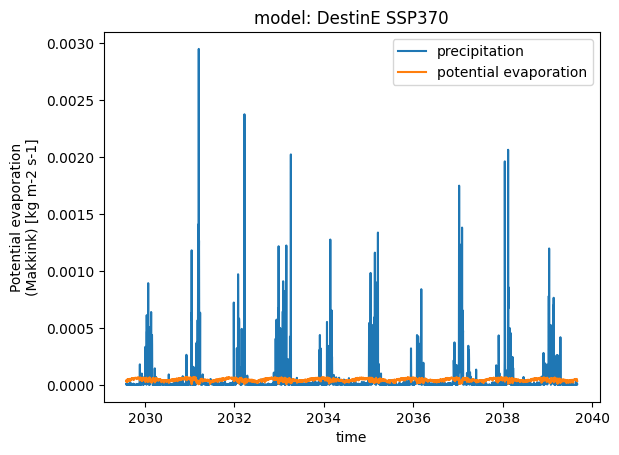

In [7]:
# Generate forcing:
try:
    DestinE_forcing_object = DestinEForcing.load(settings['path_DestinE'])
except:
    DestinE_forcing_object = DestinEForcing.generate(
       start_time=settings['future_start_date'],
       end_time=settings['future_end_date'],
       directory=settings['path_DestinE'],
       shape=settings['path_shape'],
    )

display(DestinE_forcing_object)

# Quick plot of the precipitation and potential evaporation data
plt.figure()
ds_DestinE = xr.open_mfdataset([DestinE_forcing_object['pr'],DestinE_forcing_object['evspsblpot']])
ds_DestinE["pr"].plot(label = 'precipitation')
ds_DestinE["evspsblpot"].plot(label = 'potential evaporation')
plt.legend()
plt.title('model: DestinE SSP370') 